In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
def train_test_split(data, train_percentage, test_percentage):
    rows, col = data.shape
    shuffeled_data = data.sample(frac = 1)

    train_data = shuffeled_data.head(int((rows / 100) * train_percentage))
    test_data = shuffeled_data.tail(int((rows / 100) * test_percentage))

    return train_data, test_data
    

In [27]:
data = pd.read_csv(r"C:\Coding\Machine_Learning\Machine Learning Coding\LinearRegression\Practice Problems\Gradient Descent\Practice datasets\house_prices_dataset.csv")
data.head()

,area,price
0,2231.88,558852.17
1,2524.92,632260.29
2,1527.65,382994.25
3,1986.09,497607.86
4,2920.16,730870.84


In [28]:
train_data, test_data = train_test_split(data,80,20)

In [29]:
# Training model
rows, col = train_data.shape

X_Raw = train_data['area']
Y_Raw = train_data['price']

Y = (Y_Raw - np.mean(Y_Raw)) / np.std(Y_Raw)
X = (X_Raw - np.mean(X_Raw)) / np.std(X_Raw)

# Findind w and b value using closed form 
X_Mean = np.mean(X)
Y_Mean = np.mean(Y)

# Devitation
X_Dev = X - X_Mean
Y_Dev = Y - Y_Mean

# Product of Deviation
PROD_Dev = X_Dev * Y_Dev

# Sum of product of deviations
total = 0
for i in PROD_Dev:
    total = total + i
PROD_Dev_Sum = total

# Squared Deviation
Squared_Dev = np.sum(X_Dev**2)

# Slope
w = PROD_Dev_Sum/Squared_Dev

# Intercept
b = Y_Mean - (w * X_Mean)

print (f"{w}, {b}")

0.9999995239034177, 4.371506991618613e-17


In [30]:
w = 1.5
b = 0.8
Y_pred = (w*X) + b
Y_pred.rename('PredictedPrice')

45    2.740048
68    1.128673
14    2.961025
39    2.766442
49    0.692678
        ...   
88    0.850095
66    2.253050
53    2.736244
99    3.082253
2    -1.618054
Name: PredictedPrice, Length: 80, dtype: float64

In [31]:
cost = (1/(2*rows)) * np.sum((Y_pred - Y)**2)
cost

np.float64(0.4450007141448737)

In [32]:
m = rows
# Build the grid of candidate w, b values (the "bowl" background)
w_range = np.linspace(-2,4,100)
b_range = np.linspace(-3,3,100)

W, B = np.meshgrid(w_range, b_range)

Z = np.zeros_like(W)

for row in range(W.shape[0]):
    for col in range(W.shape[1]):
        w_val = W[row, col]
        b_val = B[row, col]
        Y_pred_grid = (w_val * X) + b_val
        Z[row,col] = (1/(2*m)) * (np.sum((Y_pred_grid-Y)**2))
Z


array([[8.99999905, 8.82001744, 8.64370893, ..., 8.64371167, 8.82002024,
        9.0000019 ],
       [8.82001741, 8.64003581, 8.4637273 , ..., 8.46373004, 8.64003861,
        8.82002027],
       [8.64370887, 8.46372727, 8.28741876, ..., 8.2874215 , 8.46373007,
        8.64371173],
       ...,
       [8.64370887, 8.46372727, 8.28741876, ..., 8.2874215 , 8.46373007,
        8.64371173],
       [8.82001741, 8.64003581, 8.4637273 , ..., 8.46373004, 8.64003861,
        8.82002027],
       [8.99999905, 8.82001744, 8.64370893, ..., 8.64371167, 8.82002024,
        9.0000019 ]], shape=(100, 100))

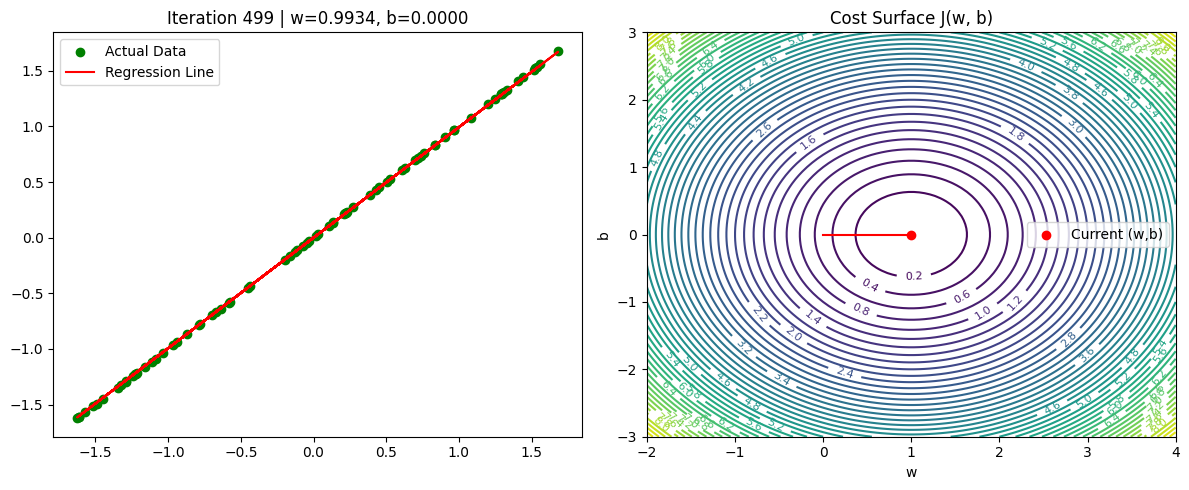

0.9934290439891875, 5.526395313593113e-17


In [33]:
iterations = 500
w = 0
b = 0
w_history = [w]
b_history = [b]
cost_history = []
ALPHA = 0.01
from IPython import display

for i in range(iterations):
    Y_Pred = (w * X) + b

    # Gradient descent update
    w = w - (ALPHA * ((1/m) * np.sum((Y_Pred - Y) * X)))
    b = b - (ALPHA * ((1/m) * np.sum(Y_Pred - Y)))

    w_history.append(w)
    b_history.append(b)

    cost = (1/m) * (np.sum((Y_Pred - Y)**2))
    cost_history.append(cost)

    # Only redraw every 10 iterations (not every single one)
    if i % 15 == 0 or i == iterations - 1:
        display.clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Left: regression line
        ax1.scatter(X, Y, color='green', label='Actual Data')
        ax1.plot(X, (X * w) + b, color='red', label='Regression Line')
        ax1.set_title(f"Iteration {i} | w={w:.4f}, b={b:.4f}")
        ax1.legend()

        # Right: cost contour with descent path
        contours = ax2.contour(W, B, Z, levels=50, cmap='viridis')
        ax2.plot(w_history, b_history, color='red')
        ax2.scatter([w], [b], color='red', label='Current (w,b)')
        ax2.clabel(contours, inline=True, fontsize=8)
        ax2.set_xlabel("w")
        ax2.set_ylabel("b")
        ax2.set_title("Cost Surface J(w, b)")
        ax2.legend()

        plt.tight_layout()
        plt.show()

print(f"{w}, {b}")

Text(0.5, 0.92, 'Cost Surface J(w, b) with Gradient Descent Path')

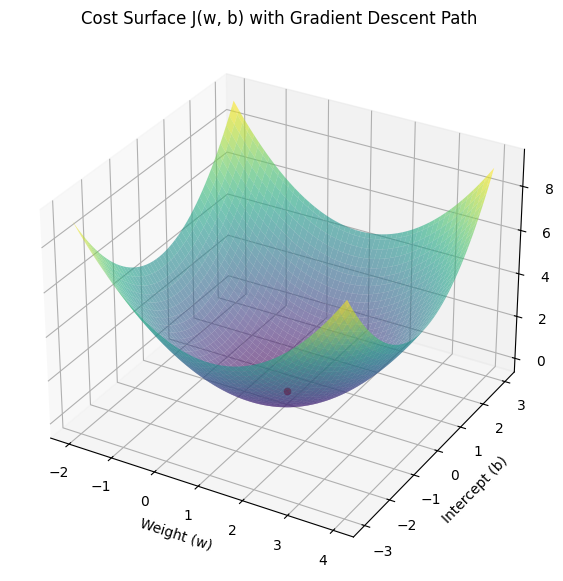

In [34]:
# Set up 3D figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw the bowl surface once (semi-transparent so the descent path is visible through it)
ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6, edgecolor='none')
ax.scatter(w,b,color = 'red')
ax.set_xlabel('Weight (w)')
ax.set_ylabel('Intercept (b)')
ax.set_zlabel('Cost (MSE)')
ax.set_title('Cost Surface J(w, b) with Gradient Descent Path')

In [35]:
w = 0.9999563504534911
b = 0
rows, col = test_data.shape
X_Test = test_data['area']
Y_Test = test_data['price']

Y_Test = (Y_Test - np.mean(Y_Test)) / np.std(Y_Test)
X_Test = (X_Test - np.mean(X_Test)) / np.std(X_Test)

Y_Test_Pred = (w * X_Test) + b

new_cost = (1/(2*rows)) * np.sum((Y_Test_Pred - Y_Test)**2)
new_cost

np.float64(3.1702966956318404e-07)

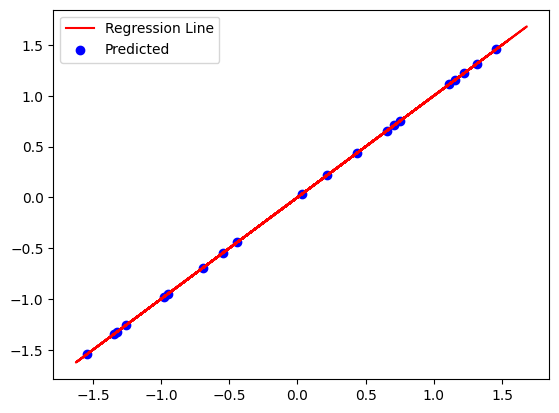

In [36]:
plt.plot(X,(X * w) + b, color = 'red',label = 'Regression Line')
plt.scatter(X_Test,Y_Test_Pred, label = 'Predicted', color = 'blue')
plt.legend()
plt.show()


In [37]:
MSE = (1/(2*rows)) * np.sum((Y_Test_Pred - Y_Test)**2)
MSE

np.float64(3.1702966956318404e-07)

In [38]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.000563053878028723)

In [39]:
R2 = 1 - (np.sum((Y_Test-Y_Test_Pred)**2)/np.sum((Y_Test-np.mean(Y_Test))**2))
R2

np.float64(0.9999993659406609)

In [40]:
new_area = 3000  # your own raw value
new_area_scaled = (new_area - np.mean(X_Raw)) / np.std(X_Raw)

Y_pred_scaled = w * new_area_scaled + b

predicted_price = (Y_pred_scaled * np.std(Y_Raw)) + np.mean(Y_Raw)

predicted_price

np.float64(750969.3831301513)